In [85]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

In [86]:
df = pd.read_csv('netflix_titles.csv')
print(df.shape)

(8807, 12)


In [87]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [88]:
print(df.isnull().sum())

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


We cannot assume the director,cast and country name so here we will use dropna()

In [89]:
df = df.dropna(subset=['country'])
df.shape

(7976, 12)

In [91]:
df = df.fillna('Unknown')
print(df.isnull().sum())

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


<Axes: xlabel='type'>

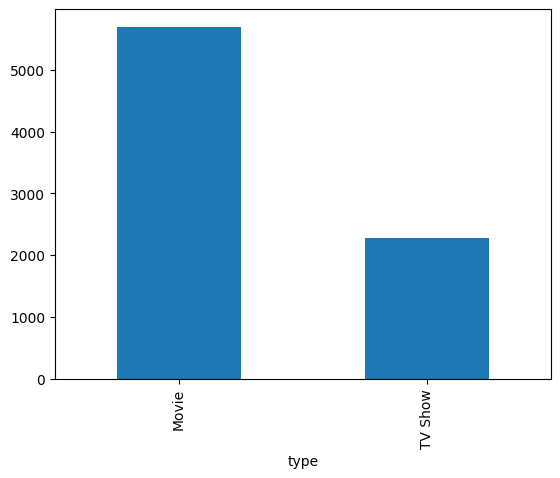

In [92]:
df['type'].value_counts().plot(kind = 'bar')


<Axes: ylabel='count'>

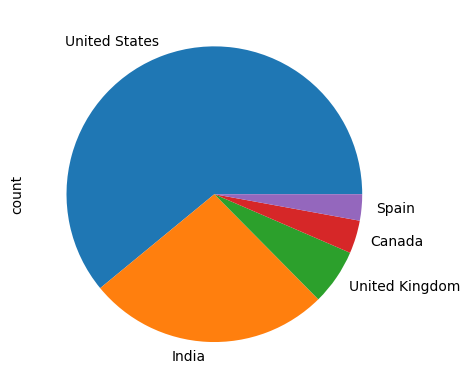

In [93]:
df[df['type'] == 'Movie']['country'].value_counts().head().plot(kind = 'pie')

In [94]:
df[(df['type'] == 'Movie') & (df['country'] == 'United States')]['director'].value_counts().head()

director
Unknown         58
Jay Karas       14
Marcus Raboy    14
Jay Chapman     12
Troy Miller      8
Name: count, dtype: int64

Text(0, 0.5, 'Count')

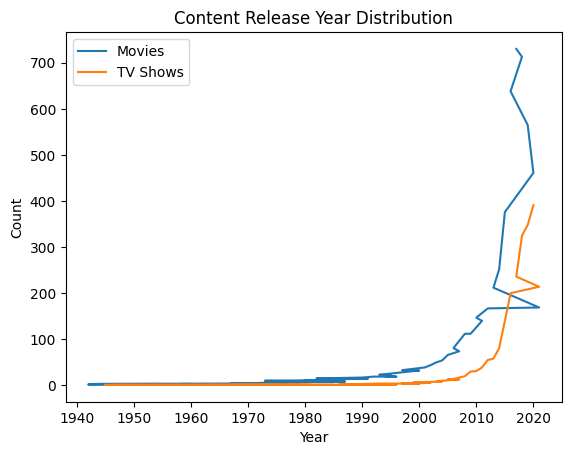

In [106]:
df[(df['type'] == 'Movie')]['release_year'].value_counts().plot(kind = 'line', label = 'Movies')
df[(df['type'] == 'TV Show')]['release_year'].value_counts().plot(kind = 'line', label='TV Shows')
plt.legend()
plt.title('Content Release Year Distribution')
plt.xlabel('Year')
plt.ylabel('Count')

## Netflix content increased dramatically after 2010, peaking around 2017-2019. The apparent drop after 2020 is likely due to dataset collection timing rather than actual decline in content.

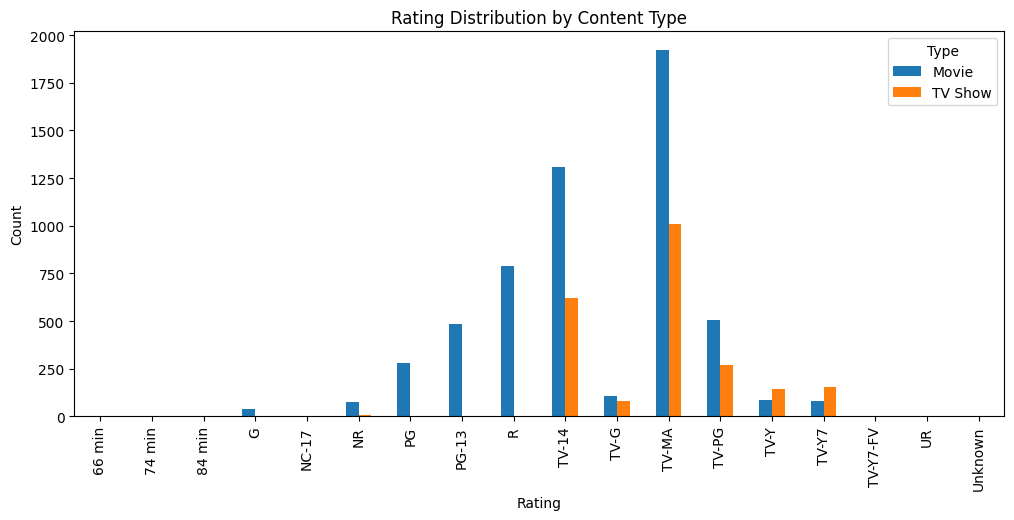

In [121]:
df.groupby(['rating', 'type']).size().unstack().plot(kind='bar', figsize=(12,5))
plt.title('Rating Distribution by Content Type')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.legend(title='Type')
plt.show()

### TV-MA (Mature Audience) dominates — Netflix targets adults, not families
### TV-14 and R are second — confirms adult content focus
### G and TV-Y (children's content) are very low — Netflix is not primarily a children's platform
### Notice "66 min", "74 min", "84 min" appearing as ratings — that's a data quality issue, duration values accidentally ended up in the rating column

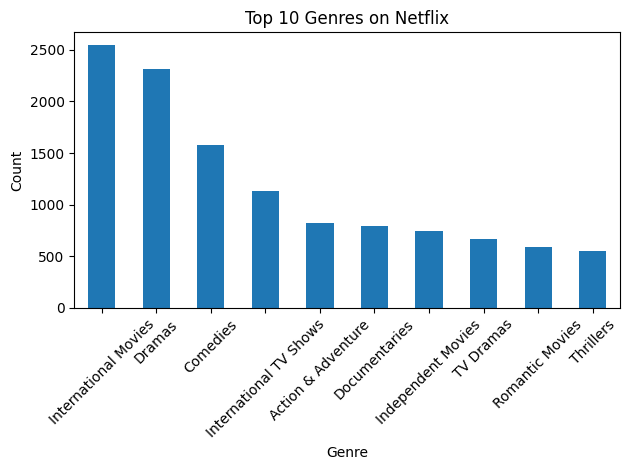

In [122]:
df['listed_in'].str.split(', ').explode().value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Genres on Netflix')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

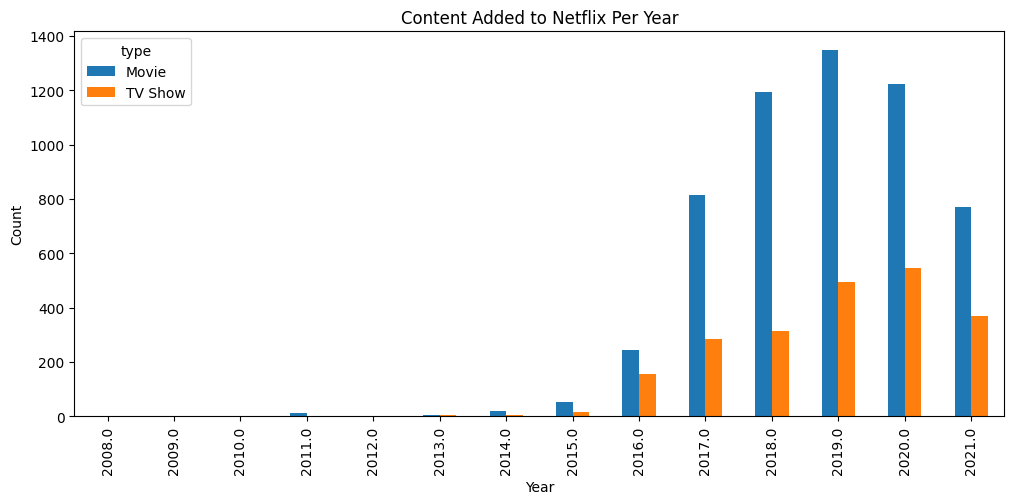

In [123]:
df['year_added'] = pd.to_datetime(df['date_added'], errors='coerce').dt.year
df.groupby('year_added')['type'].value_counts().unstack().plot(kind='bar', figsize=(12,5))
plt.title('Content Added to Netflix Per Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

# Key Observations
## 1. Netflix has significantly more Movies (5000+) than TV Shows — it's primarily a movie platform
United States and India are the top content producing countries on Netflix
TV-MA is the most common rating — Netflix primarily targets adult audiences, not families
Netflix content addition exploded after 2016, peaking in 2019 — aggressive content strategy